In [38]:
import wandb
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from scipy.stats import ks_2samp, chi2_contingency
import yaml
import random
import matplotlib.pyplot as plt
import kagglehub
import shutil
import os
from src.data_cleaning import pipeline_clean_date
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score

# Configurar semente para reprodutibilidade
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

In [50]:
wandb.login()

True

In [40]:
config = {
    "data": {
        "raw_path": "data/raw/kag_risk_factors_cervical_cancer.csv",
        "test_size": 0.2,
        "random_state": 42,
        "target_col": "Biopsy",
        "missing_threshold": 0.5,
        "imputation_strategy": "median"
    },
    "model": {
        "hidden_sizes": [64, 32],
        "dropout": 0.2,
        "learning_rate": 0.001,
        "batch_size": 32,
        "epochs": 100,
        "early_stopping_patience": 10
    }
}

In [41]:
df_raw = pd.read_csv("data/raw/kag_risk_factors_cervical_cancer.csv")

wandb.init(project="cervical-cancer-analysis", job_type="load_raw", name="load_raw")
artifact = wandb.Artifact("raw_data", type="dataset")

temp_path = "temp_raw.csv"

df_raw.to_csv(temp_path, index=False)
artifact.add_file(temp_path)
wandb.log_artifact(artifact)

wandb.summary["rows"] = len(df_raw)
wandb.summary["columns"] = list(df_raw.columns)
wandb.finish()

print("Artefato raw_data salvo no W&B")



rows,858


Artefato raw_data salvo no W&B


<h3><b>Data Set Cleaning Wandb</h3>

In [42]:

wandb.init(project="cervical-cancer-analysis", job_type="clean_data", name="clean_data")
artifact = wandb.Artifact("clean_data", type="dataset")
temp_path = "temp_clean.csv"
df_clean = pipeline_clean_date(df_raw)
df_clean.to_csv(temp_path, index=False)
artifact.add_file(temp_path)
wandb.log_artifact(artifact)
wandb.summary["rows"] = len(df_clean)
wandb.finish()

(858, 36)
Columns removed: 2
Rows removed: 98
Numbers of Duplicates Removed 19
(741, 34)


rows,741


In [43]:
from src.feature_selection import select_top_features
def split_train_test(df, target_col, test_size=0.2, random_state=42):
    print(df.columns)
    print(target_col)
    X = df.drop(columns=[target_col])
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    train_df = pd.concat([X_train, y_train], axis=1)
    test_df = pd.concat([X_test, y_test], axis=1)
    return train_df, test_df

def compare_distributions(train_df, test_df, columns):
    results = {}
    for col in columns:
        train_vals = train_df[col].dropna()
        test_vals = test_df[col].dropna()
        if train_df[col].dtype in ['int64', 'float64']:
            ks_stat, p_value = ks_2samp(train_vals, test_vals)
            results[col] = {'test': 'KS', 'statistic': ks_stat, 'p_value': p_value}
        else:
            train_counts = train_vals.value_counts(normalize=True)
            test_counts = test_vals.value_counts(normalize=True)
            all_cats = sorted(set(train_counts.index).union(set(test_counts.index)))
            train_probs = [train_counts.get(cat, 0) for cat in all_cats]
            test_probs = [test_counts.get(cat, 0) for cat in all_cats]
            chi2, p_value, _, _ = chi2_contingency([train_probs, test_probs])
            results[col] = {'test': 'Chi2', 'statistic': chi2, 'p_value': p_value}
    return results


#df_final = pipeline_feacture_selection(df_clean)

#print(f"Shape: {df_final.shape}")
#print(f"Colunas: {df_final.columns.tolist()}")
#print(f"Tem Biopsy? {'Biopsy' in df_final.columns}")

train_df, test_df = split_train_test(df_clean, 
                                     target_col=config['data']['target_col'],
                                     test_size=config['data']['test_size'],
                                     random_state=config['data']['random_state'])

#Feacture Select
print(f"Treino: {len(train_df)} amostras")
print(f"Teste:  {len(test_df)} amostras")
print(train_df.shape)
X_train = train_df.drop(columns=['Biopsy'])
y_train = train_df['Biopsy']
top_cols = select_top_features(X_train, y_train, n_top=13 ) #Numbers of select feacture, 12<15<10
train_df = train_df[top_cols + ['Biopsy']]
test_df = test_df[top_cols + ['Biopsy']]


print(f"Treino após FS: {train_df.shape}")
print(f"Teste após FS: {test_df.shape}")
print(f"Features: {top_cols}")

feature_cols = [c for c in train_df.columns if c != config['data']['target_col']]
comp_results = compare_distributions(train_df, test_df, feature_cols)

wandb.init(project="cervical-cancer-analysis", job_type="split_data", name="split_data")
train_artifact = wandb.Artifact("train_data", type="dataset")
train_df.to_csv("temp_train.csv", index=False)
train_artifact.add_file("temp_train.csv")
wandb.log_artifact(train_artifact)

test_artifact = wandb.Artifact("test_data", type="dataset")
test_df.to_csv("temp_test.csv", index=False)
test_artifact.add_file("temp_test.csv")
wandb.log_artifact(test_artifact)

comp_df = pd.DataFrame(comp_results).T
comp_table = wandb.Table(dataframe=comp_df)
wandb.log({"distribution_comparison": comp_table})

wandb.summary["train_size"] = len(train_df)
wandb.summary["test_size"] = len(test_df)

wandb.finish()
print("Artefatos de treino e teste salvos com sucesso.")

Index(['Age', 'Number of sexual partners', 'First sexual intercourse',
       'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)',
       'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD',
       'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis',
       'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis',
       'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis',
       'STDs:pelvic inflammatory disease', 'STDs:genital herpes',
       'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV',
       'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Number of diagnosis',
       'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller',
       'Citology', 'Biopsy'],
      dtype='object')
Biopsy
Treino: 592 amostras
Teste:  149 amostras
(592, 34)


c:\Users\Gabri\OneDrive\Desktop\Projeto Kaggle IA\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\Gabri\OneDrive\Desktop\Projeto Kaggle IA\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


Treino após FS: (592, 14)
Teste após FS: (149, 14)
Features: ['Schiller', 'Hinselmann', 'Dx:CIN', 'Citology', 'Hormonal Contraceptives (years)', 'Num of pregnancies', 'Number of sexual partners', 'Dx:Cancer', 'Dx', 'Dx:HPV', 'Smokes', 'IUD (years)', 'Hormonal Contraceptives']


test_size,149
train_size,592


Artefatos de treino e teste salvos com sucesso.


In [44]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_sizes, output_dim=1, dropout=0.2):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [49]:
def prepare_dataloaders(train_df, test_df, target_col, batch_size):
    X_train = train_df.drop(columns=[target_col]).values.astype(np.float32)
    y_train = train_df[target_col].values.astype(np.float32).reshape(-1, 1)
    X_test = test_df.drop(columns=[target_col]).values.astype(np.float32)
    y_test = test_df[target_col].values.astype(np.float32).reshape(-1, 1)
    
    scaler = RobustScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
    test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader, scaler

def train_model(config, train_loader, test_loader, input_dim):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = MLP(input_dim, config['model']['hidden_sizes'], dropout=config['model']['dropout']).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=config['model']['learning_rate'])
    
    best_loss = float('inf')
    patience = config['model']['early_stopping_patience']
    counter = 0

    wandb.watch(model, log="all")

    for epoch in range(config['model']['epochs']):
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        correct = 0
        all_preds = []   
        all_labels = []  
        all_probs = []

        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                output = model(X_batch)
                loss = criterion(output, y_batch)
                #Vall_loss need for see dates what not are see, if her be too much high than train_loss, mean that model is only remenber the train ago
                val_loss += loss.item() * X_batch.size(0) 
                
                threshold = 0.3
                pred = (torch.sigmoid(output) > threshold   ).float()
                probs = torch.sigmoid(output)
                correct += (pred == y_batch).sum().item()

                all_probs.extend(probs.cpu().numpy().flatten())
                all_preds.extend(pred.cpu().numpy())      #F1
                all_labels.extend(y_batch.cpu().numpy())  #F1
        try:
            #
            auc_roc = roc_auc_score(all_labels, all_probs)
        except:
            auc_roc = 0.5  

        val_loss /= len(test_loader.dataset) 
        acc = correct / len(test_loader.dataset)
        f1 = f1_score(all_labels, all_preds, zero_division=0) #New Metrics
        recall = recall_score(all_labels, all_preds, zero_division=0)      
        precision = precision_score(all_labels, all_preds, zero_division=0) 

        wandb.log({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss, "val_acc": acc,
                   "val_f1": f1, "val_auc": auc_roc,"val_recall": recall,"val_precision": precision}) #New metrics

        if val_loss < best_loss:
            best_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), "best_model.pt")
            model_artifact = wandb.Artifact("trained_model", type="model")
            model_artifact.add_file("best_model.pt")
            wandb.log_artifact(model_artifact)
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping triggered at epoch {epoch}")
                break

    model.load_state_dict(torch.load("best_model.pt"))
    return model

wandb.init(project="cervical-cancer-analysis", job_type="train", name="mlp_training", config=config)

train_df = pd.read_csv("temp_train.csv")
test_df = pd.read_csv("temp_test.csv")

train_loader, test_loader, scaler = prepare_dataloaders(
    train_df, test_df, config['data']['target_col'], config['model']['batch_size']
)
input_dim = train_loader.dataset.tensors[0].shape[1]

model = train_model(config, train_loader, test_loader, input_dim)

wandb.finish()
print("Treinamento concluído e melhor modelo salvo no W&B.")

Early stopping triggered at epoch 29


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_loss,█▇▅▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▅███████████████████████████
val_auc,▁▁▁▂▂▃▄▄▅▆▇███████████████████
val_f1,▂▂▁▁▁▁▁▁▃▃▃▃▃▇▇▇█▇▇██▇█▇██▇▇██
val_loss,█▆▅▄▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_precision,▂▁▁▁▁▁▁▁█████▇▇▇▆▆▆▅▅▅▅▅▅▅▅▅▆▆
val_recall,█▆▁▁▁▁▁▁▂▂▂▂▂▄▄▅▅▅▅▇▇▆▇▅▇▇▅▅▆▆
epoch,29
train_loss,0.07305
val_acc,0.95302


Treinamento concluído e melhor modelo salvo no W&B.


              precision    recall  f1-score   support

         0.0       0.99      0.96      0.97       138
         1.0       0.64      0.82      0.72        11

    accuracy                           0.95       149
   macro avg       0.81      0.89      0.85       149
weighted avg       0.96      0.95      0.96       149

Precision: 0.6429
Recall: 0.8182
F1 Score: 0.7200
ROC AUC: 0.8745


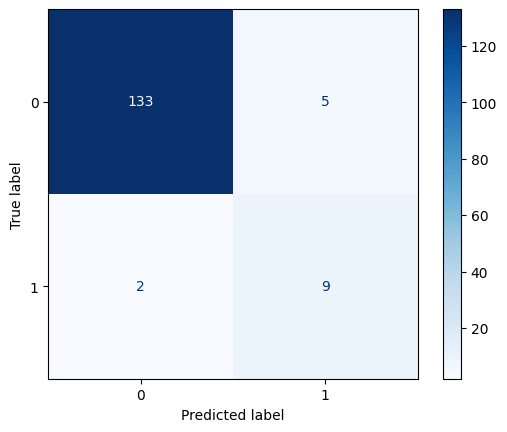

In [46]:
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    ConfusionMatrixDisplay,
    f1_score,
    roc_auc_score,
    precision_score,
    recall_score
)
import matplotlib.pyplot as plt
import torch
import numpy as np

model.eval()

y_true = []
y_pred = []
y_probs = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)

        outputs = model(X_batch)
        probs = torch.sigmoid(outputs)

        preds = (probs > 0.3).float()

        y_true.extend(y_batch.numpy())
        y_pred.extend(preds.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

# Converter para numpy
y_true = np.array(y_true).ravel()
y_pred = np.array(y_pred).ravel()
y_probs = np.array(y_probs).ravel()

# 📊 Relatório completo
print(classification_report(y_true, y_pred))

# 🎯 Métricas principais
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_probs)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")

# 📉 Matriz de confusão
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.show()